
Loading MRI volume...

Expected Voxels = 7109137
Loaded Voxels = 7109137

MRI Loaded Successfully!

MRI Shape = (181, 217, 181)

Datatype = uint8

Minimum = 0
Maximum = 255

After Normalization:
Minimum = 0.0
Maximum = 1.0


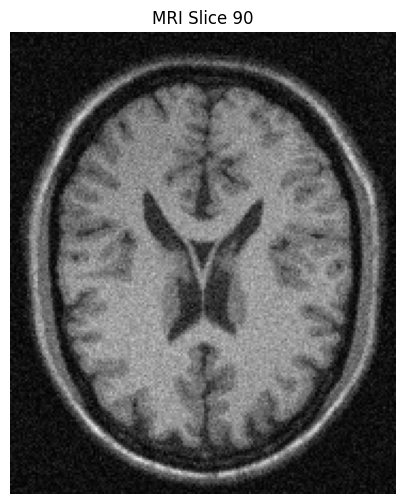


MRI Ready For 3D U-Net!


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FILE PATH
# ============================================================

MRI_PATH = "t1_icbm_normal_1mm_pn9_rf40.rawb"

# ============================================================
# MRI DIMENSIONS
# ============================================================

DEPTH  = 181
HEIGHT = 217
WIDTH  = 181

# ============================================================
# LOAD MRI
# ============================================================

print("\nLoading MRI volume...")

mri_volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

# ============================================================
# VERIFY SIZE
# ============================================================

expected_voxels = DEPTH * HEIGHT * WIDTH

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", mri_volume.size)

if mri_volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {mri_volume.size}"
    )

# ============================================================
# RESHAPE
# ============================================================

mri_volume = mri_volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nMRI Loaded Successfully!")

print("\nMRI Shape =", mri_volume.shape)

print("\nDatatype =", mri_volume.dtype)

# ============================================================
# CHECK RANGE
# ============================================================

print("\nMinimum =", np.min(mri_volume))

print("Maximum =", np.max(mri_volume))

# ============================================================
# NORMALIZE
# ============================================================

mri_volume = mri_volume.astype(np.float32)

mri_volume = mri_volume / 255.0

print("\nAfter Normalization:")

print("Minimum =", np.min(mri_volume))

print("Maximum =", np.max(mri_volume))

# ============================================================
# DISPLAY SLICE
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(6,6))

plt.imshow(
    mri_volume[slice_index],
    cmap='gray'
)

plt.title(f"MRI Slice {slice_index}")

plt.axis("off")

plt.show()

print("\nMRI Ready For 3D U-Net!")


Loading Ground Truth Volume...

Expected Voxels = 7109137
Loaded Voxels = 7109137

Ground Truth Loaded Successfully!

Ground Truth Shape = (181, 217, 181)

Datatype = uint8

Unique Labels Found:
[0 1 2 3 4 5 6 7 8 9]


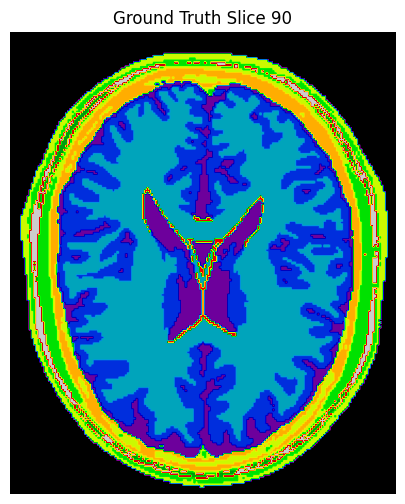


Ground Truth Ready For Training!


In [2]:
#Load Segmentation Label
# ============================================================
# LOAD SEGMENTATION LABEL VOLUME
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# GROUND TRUTH FILE
# ============================================================

GT_PATH = "phantom_1.0mm_normal_crisp.rawb"

# ============================================================
# GROUND TRUTH DIMENSIONS
# ============================================================

DEPTH  = 181
HEIGHT = 217
WIDTH  = 181

# ============================================================
# LOAD GROUND TRUTH
# ============================================================

print("\nLoading Ground Truth Volume...")

gt_volume = np.fromfile(
    GT_PATH,
    dtype=np.uint8
)

# ============================================================
# VERIFY SIZE
# ============================================================

expected_voxels = DEPTH * HEIGHT * WIDTH

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", gt_volume.size)

if gt_volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {gt_volume.size}"
    )

# ============================================================
# RESHAPE INTO 3D
# ============================================================

gt_volume = gt_volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nGround Truth Loaded Successfully!")

print("\nGround Truth Shape =", gt_volume.shape)

print("\nDatatype =", gt_volume.dtype)

# ============================================================
# CHECK LABEL VALUES
# ============================================================

unique_labels = np.unique(gt_volume)

print("\nUnique Labels Found:")

print(unique_labels)

# ============================================================
# DISPLAY MIDDLE SLICE
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(6,6))

plt.imshow(
    gt_volume[slice_index],
    cmap='nipy_spectral'
)

plt.title(f"Ground Truth Slice {slice_index}")

plt.axis("off")

plt.show()

# ============================================================
# READY
# ============================================================

print("\nGround Truth Ready For Training!")


Loading MRI Volume...

Expected Voxels = 7109137
Loaded Voxels = 7109137

MRI Shape = (181, 217, 181)

Converting To Float32...

Scaling Intensities To [0,1]...

Applying Z-Score Normalization...

Mean = 0.18926457
Std = 0.16645736

Z-Score Normalization Completed!

Final Intensity Statistics
Minimum = -1.1134562
Maximum = 4.870529
Mean = -3.4903886e-07
Std = 0.9999998


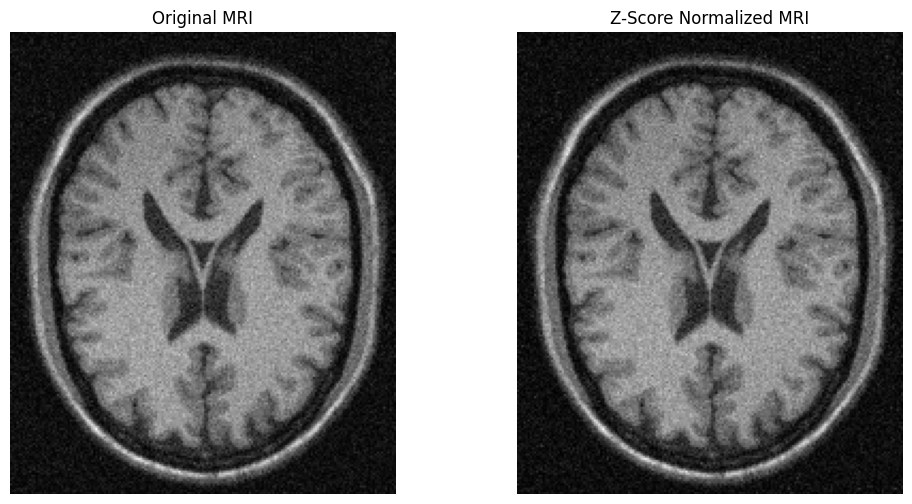


Preprocessing Completed!

Operations Applied:
- Float32 conversion
- Intensity scaling
- Z-score normalization


MRI Ready For 3D U-Net!


In [3]:
# ============================================================
# PREPROCESSING + Z-SCORE NORMALIZATION ONLY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MRI FILE
# ============================================================

MRI_PATH = "t1_icbm_normal_1mm_pn9_rf40.rawb"

# ============================================================
# MRI DIMENSIONS
# ============================================================

DEPTH  = 181
HEIGHT = 217
WIDTH  = 181

# ============================================================
# LOAD MRI
# ============================================================

print("\nLoading MRI Volume...")

volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

# ============================================================
# VERIFY SIZE
# ============================================================

expected_voxels = (
    DEPTH *
    HEIGHT *
    WIDTH
)

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", volume.size)

if volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {volume.size}"
    )

# ============================================================
# RESHAPE
# ============================================================

volume = volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nMRI Shape =", volume.shape)

# ============================================================
# CONVERT TO FLOAT32
# ============================================================

print("\nConverting To Float32...")

volume = volume.astype(np.float32)

# ============================================================
# SCALE TO [0,1]
# ============================================================

print("\nScaling Intensities To [0,1]...")

volume = volume / 255.0

# ============================================================
# Z-SCORE NORMALIZATION ONLY
# ============================================================

print("\nApplying Z-Score Normalization...")

# ------------------------------------------------------------
# USE NON-ZERO VOXELS ONLY
# ------------------------------------------------------------

brain_voxels = volume[
    volume > 0
]

mean = np.mean(
    brain_voxels
)

std = np.std(
    brain_voxels
)

print("\nMean =", mean)

print("Std =", std)

# ------------------------------------------------------------
# Z-SCORE FORMULA
# ------------------------------------------------------------

normalized_volume = (
    volume - mean
) / (
    std + 1e-8
)

# ------------------------------------------------------------
# KEEP BACKGROUND BLACK
# ------------------------------------------------------------

normalized_volume[
    volume == 0
] = 0

print("\nZ-Score Normalization Completed!")

# ============================================================
# CHECK FINAL RANGE
# ============================================================

print("\nFinal Intensity Statistics")

print("Minimum =",
      np.min(normalized_volume))

print("Maximum =",
      np.max(normalized_volume))

print("Mean =",
      np.mean(
          normalized_volume[
              volume > 0
          ]
      ))

print("Std =",
      np.std(
          normalized_volume[
              volume > 0
          ]
      ))

# ============================================================
# VISUALIZATION
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(12,6))

# ------------------------------------------------------------
# ORIGINAL MRI
# ------------------------------------------------------------

plt.subplot(1,2,1)

plt.imshow(
    volume[slice_index],
    cmap='gray'
)

plt.title("Original MRI")

plt.axis("off")

# ------------------------------------------------------------
# NORMALIZED MRI
# ------------------------------------------------------------

plt.subplot(1,2,2)

plt.imshow(
    normalized_volume[slice_index],
    cmap='gray'
)

plt.title("Z-Score Normalized MRI")

plt.axis("off")

plt.show()

# ============================================================
# FINAL INFORMATION
# ============================================================

print("\nPreprocessing Completed!")

print("""
Operations Applied:
- Float32 conversion
- Intensity scaling
- Z-score normalization
""")

print("\nMRI Ready For 3D U-Net!")


MRI Shape = (181, 217, 181)
Ground Truth Shape = (181, 217, 181)

Unique Labels After Cleanup
[0 1 2 3]

Extracting 3D Patches...

Total Valid Patches = 150

Image Patch Shape = (150, 32, 32, 32, 1)
Mask Patch Shape = (150, 32, 32, 32)

One Patch Shape = (32, 32, 32, 1)

Patch Intensity Range
Minimum = 0.0
Maximum = 1.0

Unique Labels In Mask Patches
[0 1 2 3]

Selecting Best Brain Patch...
Best Patch Index = 108


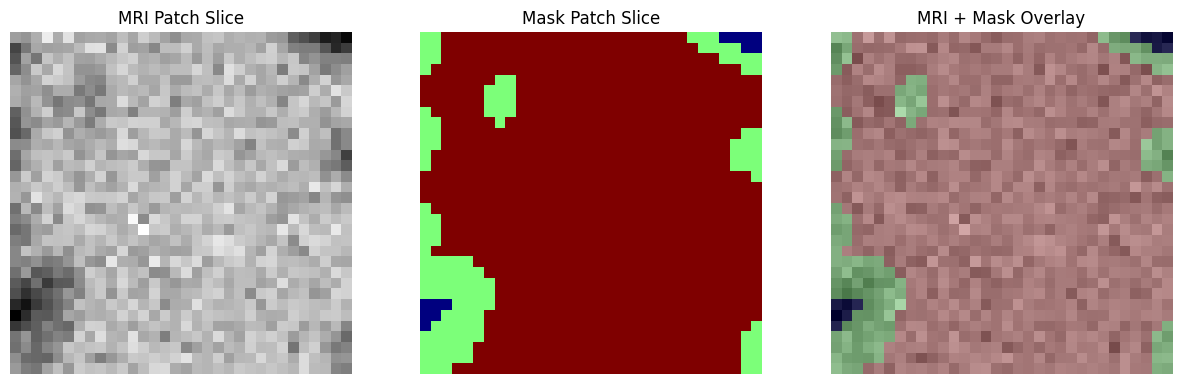


Patch Extraction Completed Successfully!

Ready For 3D U-Net Dataset Creation!

Final Dataset Information
Total Image Patches = 150
Total Mask Patches = 150
Patch Size = 32
Stride = 32


In [4]:
#Patch Extraction
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PATCH PARAMETERS
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nMRI Shape =", volume.shape)

print("Ground Truth Shape =", gt_volume.shape)

# ============================================================
# KEEP ONLY 3 CLASSES
# ============================================================

gt_volume[gt_volume > 3] = 0

print("\nUnique Labels After Cleanup")

print(np.unique(gt_volume))

# ============================================================
# PATCH STORAGE
# ============================================================

image_patches = []

mask_patches = []

DEPTH, HEIGHT, WIDTH = volume.shape

print("\nExtracting 3D Patches...")

patch_count = 0

# ============================================================
# PATCH EXTRACTION
# ============================================================

for z in range(
    0,
    DEPTH - PATCH_SIZE + 1,
    STRIDE
):

    for y in range(
        0,
        HEIGHT - PATCH_SIZE + 1,
        STRIDE
    ):

        for x in range(
            0,
            WIDTH - PATCH_SIZE + 1,
            STRIDE
        ):

            image_patch = volume[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            mask_patch = gt_volume[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            # ------------------------------------------------
            # REMOVE EMPTY PATCHES
            # ------------------------------------------------

            if np.sum(image_patch) > 5:

                image_patches.append(
                    image_patch
                )

                mask_patches.append(
                    mask_patch
                )

                patch_count += 1

# ============================================================
# CONVERT TO NUMPY ARRAYS
# ============================================================

print("\nTotal Valid Patches =",
      patch_count)

image_patches = np.array(
    image_patches,
    dtype=np.float32
)

mask_patches = np.array(
    mask_patches,
    dtype=np.uint8
)

# ============================================================
# ADD CHANNEL DIMENSION
# ============================================================

image_patches = np.expand_dims(
    image_patches,
    axis=-1
)

# ============================================================
# PATCH INFORMATION
# ============================================================

print("\nImage Patch Shape =",
      image_patches.shape)

print("Mask Patch Shape =",
      mask_patches.shape)

print("\nOne Patch Shape =",
      image_patches[0].shape)

print("\nPatch Intensity Range")

print("Minimum =",
      np.min(image_patches))

print("Maximum =",
      np.max(image_patches))

print("\nUnique Labels In Mask Patches")

print(np.unique(mask_patches))

# ============================================================
# FIND BEST PATCH
# ============================================================

print("\nSelecting Best Brain Patch...")

best_patch_index = 0

max_intensity = 0

for i in range(len(image_patches)):

    patch_sum = np.sum(
        image_patches[i]
    )

    if patch_sum > max_intensity:

        max_intensity = patch_sum

        best_patch_index = i

print("Best Patch Index =",
      best_patch_index)

# ============================================================
# VISUALIZATION
# ============================================================

sample_patch = image_patches[
    best_patch_index
]

sample_mask = mask_patches[
    best_patch_index
]

middle_slice = PATCH_SIZE // 2

plt.figure(figsize=(15,5))

# ---------------- MRI PATCH ----------------

plt.subplot(1,3,1)

plt.imshow(
    sample_patch[middle_slice,:,:,0],
    cmap='gray'
)

plt.title("MRI Patch Slice")

plt.axis("off")

# ---------------- MASK PATCH ----------------

plt.subplot(1,3,2)

plt.imshow(
    sample_mask[middle_slice],
    cmap='jet'
)

plt.title("Mask Patch Slice")

plt.axis("off")

# ---------------- OVERLAY ----------------

plt.subplot(1,3,3)

plt.imshow(
    sample_patch[middle_slice,:,:,0],
    cmap='gray'
)

plt.imshow(
    sample_mask[middle_slice],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Mask Overlay")

plt.axis("off")

plt.show()

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nPatch Extraction Completed Successfully!")

print("\nReady For 3D U-Net Dataset Creation!")

print("\nFinal Dataset Information")

print("Total Image Patches =",
      len(image_patches))

print("Total Mask Patches =",
      len(mask_patches))

print("Patch Size =",
      PATCH_SIZE)

print("Stride =",
      STRIDE)

In [5]:
# ============================================================
# CONVERT PATCHES TO PYTORCH FORMAT
# ATTENTION Residual 3D U-NET
# PATCH SIZE = 32
# STRIDE = 32
# ============================================================

import torch
import numpy as np

print("\nConverting Patches To PyTorch Tensors...")

# ============================================================
# PATCH + STRIDE CONFIGURATION
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nPatch Size =", PATCH_SIZE)
print("Stride =", STRIDE)

# ============================================================
# NUMPY -> TORCH
# ============================================================

print("\nChecking Input Types...")

if isinstance(image_patches, np.ndarray):

    print("Converting Image Patches To Tensor...")

    image_patches = torch.from_numpy(
        image_patches
    ).float()

if isinstance(mask_patches, np.ndarray):

    print("Converting Mask Patches To Tensor...")

    mask_patches = torch.from_numpy(
        mask_patches
    ).long()

# ============================================================
# CURRENT SHAPES
# ============================================================

print("\nCurrent Image Tensor Shape =",
      image_patches.shape)

print("Current Mask Tensor Shape =",
      mask_patches.shape)

# ============================================================
# CURRENT FORMAT
# ============================================================

print("\nCurrent Tensor Format")

print("""
Images:
[B, D, H, W, C]

Masks:
[B, D, H, W]
""")

# ============================================================
# REQUIRED FORMAT FOR ATTENTION Residual 3D U-NET
# ============================================================

print("\nRequired Format")

print("""
Images:
[B, C, D, H, W]

Masks:
[B, D, H, W]
""")

# ============================================================
# REORDER DIMENSIONS
# ============================================================

if len(image_patches.shape) == 5:

    print("\nReordering Tensor Dimensions...")

    image_patches = image_patches.permute(
        0, 4, 1, 2, 3
    )

# ============================================================
# ENSURE CONTIGUOUS MEMORY
# ============================================================

print("\nMaking Tensors Contiguous...")

image_patches = image_patches.contiguous()

mask_patches = mask_patches.contiguous()

# ============================================================
# FINAL SHAPES
# ============================================================

print("\nFinal Image Tensor Shape =",
      image_patches.shape)

print("Final Mask Tensor Shape =",
      mask_patches.shape)

# ============================================================
# DIMENSION MEANING
# ============================================================

print("\nTensor Dimension Meaning")

print("""
Images:
[Batch, Channel, Depth, Height, Width]

Masks:
[Batch, Depth, Height, Width]
""")

# ============================================================
# DIMENSION INTERPRETATION
# ============================================================

print("\nDimension Interpretation")

print("Batch Size =",
      image_patches.shape[0])

print("Channels =",
      image_patches.shape[1])

print("Depth =",
      image_patches.shape[2])

print("Height =",
      image_patches.shape[3])

print("Width =",
      image_patches.shape[4])

# ============================================================
# PATCH INFORMATION
# ============================================================

print("\nPatch Information")

print(f"""
Patch Shape:

{PATCH_SIZE} × {PATCH_SIZE} × {PATCH_SIZE}

Stride = {STRIDE}
""")

# ============================================================
# OVERLAP INFORMATION
# ============================================================

overlap = PATCH_SIZE - STRIDE

print("\nPatch Overlap")

print("Overlap =", overlap)

if overlap == 0:

    print("""
No overlap exists.

Each patch is processed independently.
""")

else:

    print(f"""
Overlap Percentage =
{(overlap / PATCH_SIZE) * 100:.2f}%
""")

# ============================================================
# ATTENTION Residual U-NET INFORMATION
# ============================================================

print("\nAttention Residual 3D U-Net Input Requirements")

print("""
Attention Residual U-Net expects:

Input:
[B, C, D, H, W]

Example:
[2, 1, 32, 32, 32]
""")

print("""
The attention Residual gates operate on:

- encoder feature maps
- decoder feature maps

Correct tensor ordering is essential.
""")

# ============================================================
# VERIFY LABELS
# ============================================================

print("\nUnique Labels In Mask Tensor")

print(torch.unique(mask_patches))

# ============================================================
# LABEL INTERPRETATION
# ============================================================

print("\nLabel Meaning")

print("""
0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter
""")

# ============================================================
# VERIFY DTYPE
# ============================================================

print("\nImage Tensor Dtype =",
      image_patches.dtype)

print("Mask Tensor Dtype =",
      mask_patches.dtype)

# ============================================================
# VERIFY SHAPE COMPATIBILITY
# ============================================================

print("\nVerifying Shape Compatibility...")

if image_patches.shape[2] == PATCH_SIZE:

    print("Depth Compatible")

if image_patches.shape[3] == PATCH_SIZE:

    print("Height Compatible")

if image_patches.shape[4] == PATCH_SIZE:

    print("Width Compatible")

# ============================================================
# ATTENTION Residual MODEL PIPELINE
# ============================================================

print("\nAttention Residual 3D U-Net Pipeline")

print("""
MRI Volume
     ↓
Patch Extraction
(32×32×32)
     ↓
Tensor Conversion
[B,C,D,H,W]
     ↓
Attention Residual 3D U-Net
     ↓
Attention Residual Gates
     ↓
Softmax Probabilities
     ↓
Segmentation Prediction
""")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n================================================")
print("FINAL SUMMARY")
print("================================================")

print("\nModel Type = Attention Residual 3D U-Net")

print("\nPatch Size =", PATCH_SIZE)

print("Stride =", STRIDE)

print("\nFinal Image Tensor Shape =")

print(image_patches.shape)

print("\nFinal Mask Tensor Shape =")

print(mask_patches.shape)

print("\nPyTorch Tensor Preparation Completed Successfully!")



Converting Patches To PyTorch Tensors...

Patch Size = 32
Stride = 32

Checking Input Types...
Converting Image Patches To Tensor...
Converting Mask Patches To Tensor...

Current Image Tensor Shape = torch.Size([150, 32, 32, 32, 1])
Current Mask Tensor Shape = torch.Size([150, 32, 32, 32])

Current Tensor Format

Images:
[B, D, H, W, C]

Masks:
[B, D, H, W]


Required Format

Images:
[B, C, D, H, W]

Masks:
[B, D, H, W]


Reordering Tensor Dimensions...

Making Tensors Contiguous...

Final Image Tensor Shape = torch.Size([150, 1, 32, 32, 32])
Final Mask Tensor Shape = torch.Size([150, 32, 32, 32])

Tensor Dimension Meaning

Images:
[Batch, Channel, Depth, Height, Width]

Masks:
[Batch, Depth, Height, Width]


Dimension Interpretation
Batch Size = 150
Channels = 1
Depth = 32
Height = 32
Width = 32

Patch Information

Patch Shape:

32 × 32 × 32

Stride = 32


Patch Overlap
Overlap = 0

No overlap exists.

Each patch is processed independently.


Attention Residual 3D U-Net Input Require

In [6]:
# ============================================================
# ATTENTION 3D U-NET TRAINING + INFERENCE
# PATCH SIZE = 32
# STRIDE = 32
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice =", DEVICE)

# ============================================================
# PATCH CONFIGURATION
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nPatch Size =", PATCH_SIZE)
print("Stride =", STRIDE)

# ============================================================
# NUMBER OF CLASSES
# ============================================================

NUM_CLASSES = 4

print("\nClass Meaning")

print("""
0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter
""")

# ============================================================
# CREATE DATASET
# ============================================================

print("\nCreating TensorDataset...")

dataset = TensorDataset(
    image_patches,
    mask_patches
)

print("\nDataset Created Successfully!")

print("\nTotal Samples =",
      len(dataset))

# ============================================================
# CREATE DATALOADER
# ============================================================

BATCH_SIZE = 2

print("\nCreating DataLoader...")

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("\nDataLoader Created Successfully!")

# ============================================================
# VERIFY ONE BATCH
# ============================================================

print("\nChecking One Batch...")

sample_images, sample_masks = next(
    iter(loader)
)

print("\nImage Batch Shape =",
      sample_images.shape)

print("Mask Batch Shape =",
      sample_masks.shape)

print("\nTensor Meaning")

print("""
Images:
[Batch, Channel, Depth, Height, Width]

Masks:
[Batch, Depth, Height, Width]
""")

import torch
import torch.nn as nn

# ============================================================
# RESIDUAL BLOCK
# ============================================================

class ResidualBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv1 = nn.Conv3d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.bn1 = nn.BatchNorm3d(
            out_channels
        )

        self.conv2 = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm3d(
            out_channels
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        if in_channels != out_channels:

            self.shortcut = nn.Sequential(

                nn.Conv3d(
                    in_channels,
                    out_channels,
                    kernel_size=1
                ),

                nn.BatchNorm3d(
                    out_channels
                )
            )

        else:

            self.shortcut = nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity

        out = self.relu(out)

        return out


# ============================================================
# ATTENTION GATE
# ============================================================

class AttentionBlock(nn.Module):

    def __init__(
        self,
        F_g,
        F_l,
        F_int
    ):

        super().__init__()

        self.W_g = nn.Sequential(

            nn.Conv3d(
                F_g,
                F_int,
                kernel_size=1
            ),

            nn.BatchNorm3d(F_int)
        )

        self.W_x = nn.Sequential(

            nn.Conv3d(
                F_l,
                F_int,
                kernel_size=1
            ),

            nn.BatchNorm3d(F_int)
        )

        self.psi = nn.Sequential(

            nn.Conv3d(
                F_int,
                1,
                kernel_size=1
            ),

            nn.BatchNorm3d(1),

            nn.Sigmoid()
        )

        self.relu = nn.ReLU(
            inplace=True
        )

    def forward(self, g, x):

        g1 = self.W_g(g)

        x1 = self.W_x(x)

        psi = self.relu(
            g1 + x1
        )

        psi = self.psi(psi)

        return x * psi


# ============================================================
# RESIDUAL ATTENTION 3D U-NET
# ============================================================

class ResidualAttentionUNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=4
    ):

        super().__init__()

        # Encoder

        self.enc1 = ResidualBlock(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = ResidualBlock(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = ResidualBlock(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(2)

        # Bottleneck

        self.bottleneck = ResidualBlock(
            128,
            256
        )

        # Decoder 3

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.att3 = AttentionBlock(
            128,
            128,
            64
        )

        self.dec3 = ResidualBlock(
            256,
            128
        )

        # Decoder 2

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.att2 = AttentionBlock(
            64,
            64,
            32
        )

        self.dec2 = ResidualBlock(
            128,
            64
        )

        # Decoder 1

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.att1 = AttentionBlock(
            32,
            32,
            16
        )

        self.dec1 = ResidualBlock(
            64,
            32
        )

        # Output

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)

        a3 = self.att3(
            g=u3,
            x=e3
        )

        d3 = self.dec3(
            torch.cat(
                [u3, a3],
                dim=1
            )
        )

        u2 = self.up2(d3)

        a2 = self.att2(
            g=u2,
            x=e2
        )

        d2 = self.dec2(
            torch.cat(
                [u2, a2],
                dim=1
            )
        )

        u1 = self.up1(d2)

        a1 = self.att1(
            g=u1,
            x=e1
        )

        d1 = self.dec1(
            torch.cat(
                [u1, a1],
                dim=1
            )
        )

        out = self.final(d1)

        return out

# ============================================================
# CREATE MODEL
# ============================================================

print("\nCreating Attention 3D U-Net...")

model = ResidualAttentionUNet3D(
    in_channels=1,
    out_channels=NUM_CLASSES
).to(DEVICE)

print("\nAttention 3D U-Net Created Successfully!")

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("\nOptimizer Created Successfully!")

# ============================================================
# TRAINING PARAMETERS
# ============================================================

EPOCHS = 30

# ============================================================
# TRAINING LOOP
# ============================================================

print("\nStarting Training...")

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # --------------------------------------------------------
    # BATCH LOOP
    # --------------------------------------------------------

    for batch_index, (images, masks) in enumerate(loader):

        images = images.to(DEVICE)

        masks = masks.to(DEVICE)

        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        outputs = model(images)

        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            masks
        )

        # ----------------------------------------------------
        # CLEAR OLD GRADIENTS
        # ----------------------------------------------------

        optimizer.zero_grad()

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        loss.backward()

        # ----------------------------------------------------
        # UPDATE WEIGHTS
        # ----------------------------------------------------

        optimizer.step()

        # ----------------------------------------------------
        # TRACK LOSS
        # ----------------------------------------------------

        running_loss += loss.item()

        print(
            f"Batch {batch_index+1} "
            f"Loss = {loss.item():.4f}"
        )

    # --------------------------------------------------------
    # EPOCH LOSS
    # --------------------------------------------------------

    epoch_loss = (
        running_loss / len(loader)
    )

    print(
        f"\nEpoch {epoch+1} "
        f"Average Loss = "
        f"{epoch_loss:.4f}"
    )

# ============================================================
# TRAINING COMPLETE
# ============================================================

print("\nTraining Completed Successfully!")



Device = cpu

Patch Size = 32
Stride = 32

Class Meaning

0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter


Creating TensorDataset...

Dataset Created Successfully!

Total Samples = 150

Creating DataLoader...

DataLoader Created Successfully!

Checking One Batch...

Image Batch Shape = torch.Size([2, 1, 32, 32, 32])
Mask Batch Shape = torch.Size([2, 32, 32, 32])

Tensor Meaning

Images:
[Batch, Channel, Depth, Height, Width]

Masks:
[Batch, Depth, Height, Width]


Creating Attention 3D U-Net...

Attention 3D U-Net Created Successfully!


C:\Users\jksing\AppData\Roaming\Python\Python310\site-packages\torch\cuda\__init__.py:129: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 10010). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10\cuda\CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0



Optimizer Created Successfully!

Starting Training...

Epoch 1/30
Batch 1 Loss = 1.2002
Batch 2 Loss = 1.4407
Batch 3 Loss = 1.2838
Batch 4 Loss = 1.5423
Batch 5 Loss = 1.0350
Batch 6 Loss = 1.2057
Batch 7 Loss = 1.0836
Batch 8 Loss = 1.2824
Batch 9 Loss = 1.1549
Batch 10 Loss = 1.3066
Batch 11 Loss = 1.2645
Batch 12 Loss = 0.9768
Batch 13 Loss = 0.9885
Batch 14 Loss = 1.2077
Batch 15 Loss = 1.1674
Batch 16 Loss = 0.7837
Batch 17 Loss = 0.9222
Batch 18 Loss = 1.0175
Batch 19 Loss = 1.0096
Batch 20 Loss = 0.9826
Batch 21 Loss = 0.8895
Batch 22 Loss = 1.1330
Batch 23 Loss = 1.0072
Batch 24 Loss = 1.0223
Batch 25 Loss = 1.2590
Batch 26 Loss = 0.8247
Batch 27 Loss = 1.4733
Batch 28 Loss = 1.0837
Batch 29 Loss = 1.0132
Batch 30 Loss = 1.1879
Batch 31 Loss = 0.8064
Batch 32 Loss = 1.0342
Batch 33 Loss = 1.2062
Batch 34 Loss = 1.0521
Batch 35 Loss = 1.0116
Batch 36 Loss = 0.6428
Batch 37 Loss = 1.0583
Batch 38 Loss = 0.9940
Batch 39 Loss = 1.1281
Batch 40 Loss = 0.8867
Batch 41 Loss = 0.8454


Saving Attention 3D U-Net Model...

Model Saved Successfully!

Saved Model File:
AttentionResidual32x32_9_40.pth

STEP 14 — PROBABILITY MAPS

Loading Trained Attention U-Net Model...

Model Loaded Successfully!

MRI Volume Shape = (181, 217, 181)

Creating Empty Prediction Volume...

Starting Sliding Window Inference...
Processed Patch 1


C:\Users\jksing\AppData\Local\Temp\ipykernel_10352\1444354412.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Processed Patch 2
Processed Patch 3
Processed Patch 4
Processed Patch 5
Processed Patch 6
Processed Patch 7
Processed Patch 8
Processed Patch 9
Processed Patch 10
Processed Patch 11
Processed Patch 12
Processed Patch 13
Processed Patch 14
Processed Patch 15
Processed Patch 16
Processed Patch 17
Processed Patch 18
Processed Patch 19
Processed Patch 20
Processed Patch 21
Processed Patch 22
Processed Patch 23
Processed Patch 24
Processed Patch 25
Processed Patch 26
Processed Patch 27
Processed Patch 28
Processed Patch 29
Processed Patch 30
Processed Patch 31
Processed Patch 32
Processed Patch 33
Processed Patch 34
Processed Patch 35
Processed Patch 36
Processed Patch 37
Processed Patch 38
Processed Patch 39
Processed Patch 40
Processed Patch 41
Processed Patch 42
Processed Patch 43
Processed Patch 44
Processed Patch 45
Processed Patch 46
Processed Patch 47
Processed Patch 48
Processed Patch 49
Processed Patch 50
Processed Patch 51
Processed Patch 52
Processed Patch 53
Processed Patch 54
P

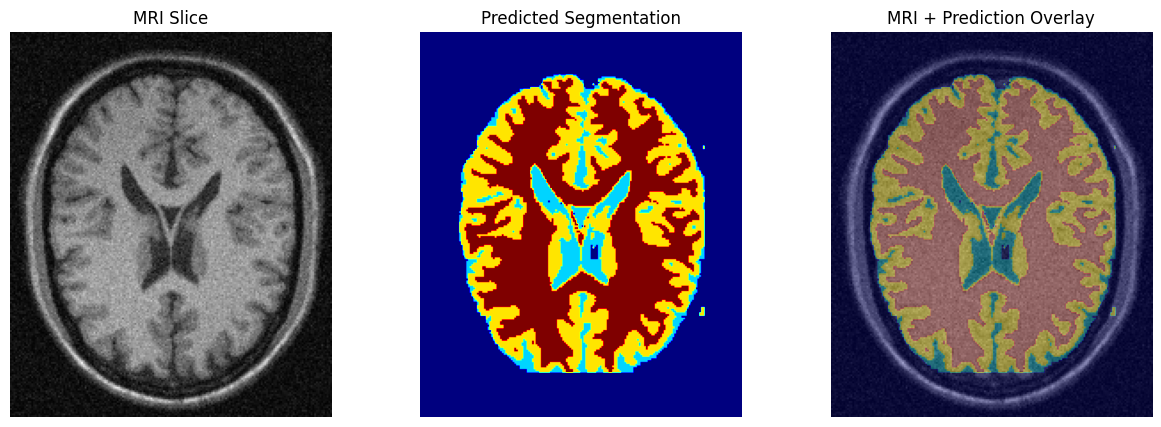


Saving Final Segmentation...

Segmentation Saved Successfully!

Inference Completed Successfully!

Attention U-Net Workflow

MRI Volume
     ↓
32×32×32 Patch Extraction
     ↓
Attention 3D U-Net
     ↓
Attention Gates
     ↓
Softmax Probability Maps
     ↓
Patch Reconstruction
     ↓
Final Brain Segmentation


Attention 3D Brain Segmentation Completed!


In [7]:

# ============================================================
# SAVE MODEL
# ============================================================

print("\nSaving Attention 3D U-Net Model...")

MODEL_PATH = "AttentionResidual32x32_9_40.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("\nModel Saved Successfully!")

print("\nSaved Model File:")

print(MODEL_PATH)

# ============================================================
# STEP 14 — PROBABILITY MAPS
# ============================================================

print("\n================================================")
print("STEP 14 — PROBABILITY MAPS")
print("================================================")

# ============================================================
# LOAD TRAINED MODEL
# ============================================================

print("\nLoading Trained Attention U-Net Model...")

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )
)

model = model.to(DEVICE)

model.eval()

print("\nModel Loaded Successfully!")

# ============================================================
# MRI VOLUME
# ============================================================

input_volume = volume

DEPTH, HEIGHT, WIDTH = input_volume.shape

print("\nMRI Volume Shape =",
      input_volume.shape)

# ============================================================
# CREATE EMPTY PREDICTION VOLUME
# ============================================================

print("\nCreating Empty Prediction Volume...")

prediction_volume = np.zeros(
    (
        NUM_CLASSES,
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

# ============================================================
# CREATE COUNT VOLUME
# ============================================================

count_volume = np.zeros(
    (
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

# ============================================================
# SLIDING WINDOW INFERENCE
# ============================================================

print("\nStarting Sliding Window Inference...")

patch_count = 0

with torch.no_grad():

    for z in range(
        0,
        DEPTH - PATCH_SIZE + 1,
        STRIDE
    ):

        for y in range(
            0,
            HEIGHT - PATCH_SIZE + 1,
            STRIDE
        ):

            for x in range(
                0,
                WIDTH - PATCH_SIZE + 1,
                STRIDE
            ):

                # ------------------------------------------------
                # EXTRACT PATCH
                # ------------------------------------------------

                patch = input_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                # ------------------------------------------------
                # SKIP EMPTY PATCHES
                # ------------------------------------------------

                if np.sum(patch) < 5:

                    continue

                # ------------------------------------------------
                # CONVERT TO TENSOR
                # ------------------------------------------------

                patch_tensor = torch.tensor(
                    patch,
                    dtype=torch.float32
                )

                patch_tensor = patch_tensor.unsqueeze(0)

                patch_tensor = patch_tensor.unsqueeze(0)

                patch_tensor = patch_tensor.to(DEVICE)

                # ------------------------------------------------
                # MODEL PREDICTION
                # ------------------------------------------------

                outputs = model(
                    patch_tensor
                )

                # ------------------------------------------------
                # SOFTMAX
                # ------------------------------------------------

                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )

                probabilities = probabilities.cpu().numpy()[0]

                # ------------------------------------------------
                # STORE PREDICTIONS
                # ------------------------------------------------

                prediction_volume[
                    :,
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += probabilities

                # ------------------------------------------------
                # UPDATE COUNT
                # ------------------------------------------------

                count_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += 1

                patch_count += 1

                print(
                    f"Processed Patch {patch_count}"
                )

# ============================================================
# AVERAGE PREDICTIONS
# ============================================================

print("\nTotal Predicted Patches =",
      patch_count)

print("\nAveraging Predictions...")

prediction_volume = prediction_volume / (
    count_volume[np.newaxis, ...] + 1e-8
)

print("\nPrediction Volume Shape =",
      prediction_volume.shape)

# ============================================================
# FINAL SEGMENTATION
# ============================================================

print("\nConverting Probabilities To Labels...")

AttentionResidual32x32_9_40 = np.argmax(
    prediction_volume,
    axis=0
)

print("\nFinal Segmentation Shape =",
      AttentionResidual32x32_9_40.shape)

# ============================================================
# UNIQUE LABELS
# ============================================================

print("\nUnique Predicted Labels")

print(np.unique(AttentionResidual32x32_9_40))

# ============================================================
# VISUALIZATION
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(15,5))

# ------------------------------------------------------------
# MRI
# ------------------------------------------------------------

plt.subplot(1,3,1)

plt.imshow(
    input_volume[slice_index],
    cmap='gray'
)

plt.title("MRI Slice")

plt.axis("off")

# ------------------------------------------------------------
# SEGMENTATION
# ------------------------------------------------------------

plt.subplot(1,3,2)

plt.imshow(
    AttentionResidual32x32_9_40[slice_index],
    cmap='jet'
)

plt.title("Predicted Segmentation")

plt.axis("off")

# ------------------------------------------------------------
# OVERLAY
# ------------------------------------------------------------

plt.subplot(1,3,3)

plt.imshow(
    input_volume[slice_index],
    cmap='gray'
)

plt.imshow(
    AttentionResidual32x32_9_40[slice_index],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Prediction Overlay")

plt.axis("off")

plt.show()

# ============================================================
# SAVE SEGMENTATION
# ============================================================

print("\nSaving Final Segmentation...")

np.save(
    "AttentionResidual32x32_9_40.npy",
    AttentionResidual32x32_9_40
)

print("\nSegmentation Saved Successfully!")

# ============================================================
# COMPLETE WORKFLOW
# ============================================================

print("\nInference Completed Successfully!")

print("\nAttention U-Net Workflow")

print("""
MRI Volume
     ↓
32×32×32 Patch Extraction
     ↓
Attention 3D U-Net
     ↓
Attention Gates
     ↓
Softmax Probability Maps
     ↓
Patch Reconstruction
     ↓
Final Brain Segmentation
""")

print("\nAttention 3D Brain Segmentation Completed!")



Visualization RAW Saved Successfully!
Saved File = AttentionResidual32x32_9_40.raw

Loaded Shape = (181, 217, 181)
Unique Intensities = [  0  45 111 150]


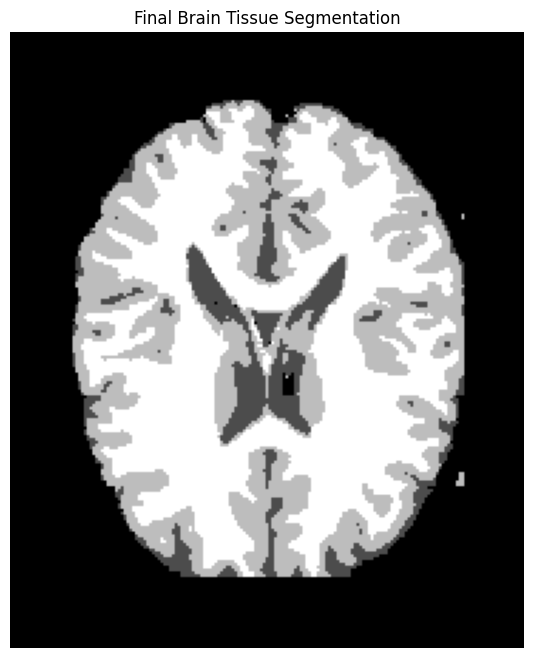


Intensity Mapping:

0   = Background
85  = CSF
170 = Gray Matter
255 = White Matter



In [8]:
# ============================================================
# SAVE SEGMENTATION FOR FIJI VISUALIZATION
# ============================================================

import numpy as np

# ============================================================
# CREATE VISUALIZATION VOLUME
# ============================================================

visual_volume = np.zeros(
    AttentionResidual32x32_9_40.shape,
    dtype=np.uint8
)

# ============================================================
# ASSIGN BRIGHTER INTENSITIES
# ============================================================

# ------------------------------------------------------------
# BACKGROUND = 0
# ------------------------------------------------------------

visual_volume[
    AttentionResidual32x32_9_40 == 0
] = 0

# ------------------------------------------------------------
# CSF = 85
# ------------------------------------------------------------

visual_volume[
    AttentionResidual32x32_9_40 == 1
] = 45

# ------------------------------------------------------------
# GRAY MATTER = 170
# ------------------------------------------------------------

visual_volume[
    AttentionResidual32x32_9_40 == 2
] = 111

# ------------------------------------------------------------
# WHITE MATTER = 255
# ------------------------------------------------------------

visual_volume[
    AttentionResidual32x32_9_40 == 3
] = 150

# ============================================================
# SAVE RAW FILE
# ============================================================

output_path = "AttentionResidual32x32_9_40.raw"

visual_volume.tofile(
    output_path
)

print("\nVisualization RAW Saved Successfully!")

print("Saved File =", output_path)

# ============================================================
# VERIFY SAVED FILE
# ============================================================

loaded_volume = np.fromfile(
    output_path,
    dtype=np.uint8
)

loaded_volume = loaded_volume.reshape(
    181,
    217,
    181
)

print("\nLoaded Shape =",
      loaded_volume.shape)

print("Unique Intensities =",
      np.unique(loaded_volume))

# ============================================================
# VISUALIZE ONE SLICE
# ============================================================

import matplotlib.pyplot as plt

slice_index = 90

plt.figure(figsize=(8,8))

plt.imshow(
    loaded_volume[slice_index],
    cmap='gray'
)

plt.title(
    "Final Brain Tissue Segmentation"
)

plt.axis("off")

plt.show()

# ============================================================
# FINAL INFORMATION
# ============================================================

print("""
Intensity Mapping:

0   = Background
85  = CSF
170 = Gray Matter
255 = White Matter
""")


RAW Files Saved Successfully!

Saved Files:

1. AttentionResidual32x32_9_40_csf.raw
2. AttentionResidual32x32_9_40_gm.raw
3. AttentionResidual32x32_9_40_wm.raw


CSF Unique Values = [ 0 45]
GM Unique Values = [  0 111]
WM Unique Values = [  0 150]


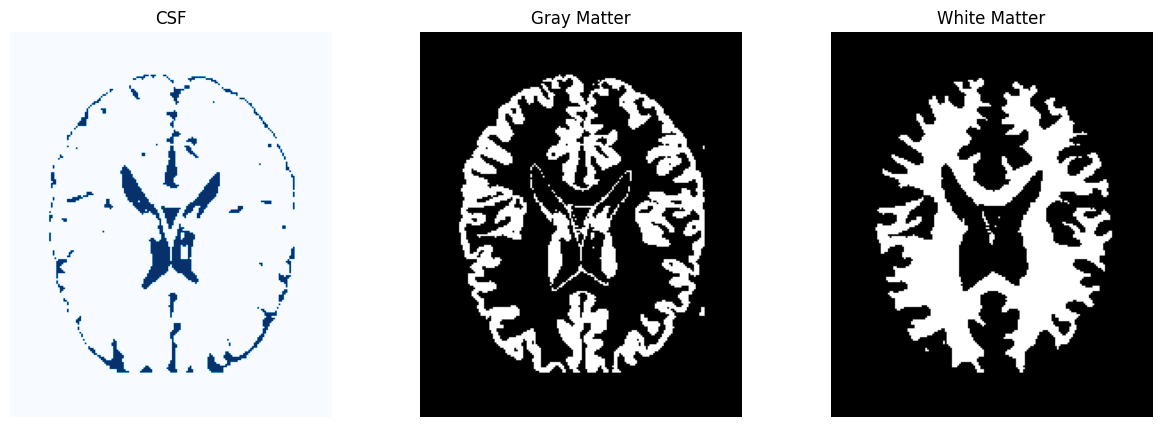


Segmentation Labels:

1 = CSF
2 = Gray Matter
3 = White Matter



In [9]:
# ============================================================
# SAVE CSF, GRAY MATTER, WHITE MATTER
# AS SEPARATE RAW FILES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CREATE EMPTY VOLUMES
# ============================================================

csf_volume = np.zeros(
    AttentionResidual32x32_9_40.shape,
    dtype=np.uint8
)

gm_volume = np.zeros(
    AttentionResidual32x32_9_40.shape,
    dtype=np.uint8
)

wm_volume = np.zeros(
    AttentionResidual32x32_9_40.shape,
    dtype=np.uint8
)

# ============================================================
# ASSIGN COLORS / INTENSITIES
# ============================================================

# ------------------------------------------------------------
# CSF → BRIGHT BLUE STYLE INTENSITY
# ------------------------------------------------------------

csf_volume[
    AttentionResidual32x32_9_40 == 1
] = 45

# ------------------------------------------------------------
# GRAY MATTER → MEDIUM GRAY
# ------------------------------------------------------------

gm_volume[
    AttentionResidual32x32_9_40 == 2
] = 111

# ------------------------------------------------------------
# WHITE MATTER → WHITE
# ------------------------------------------------------------

wm_volume[
    AttentionResidual32x32_9_40 == 3
] = 150

# ============================================================
# SAVE RAW FILES
# ============================================================

csf_volume.tofile(
    "AttentionResidual32x32_9_40_csf.raw"
)

gm_volume.tofile(
    "AttentionResidual32x32_9_40_gm.raw"
)

wm_volume.tofile(
    "AttentionResidual32x32_9_40_wm.raw"
)

print("\nRAW Files Saved Successfully!")

print("""
Saved Files:

1. AttentionResidual32x32_9_40_csf.raw
2. AttentionResidual32x32_9_40_gm.raw
3. AttentionResidual32x32_9_40_wm.raw
""")

# ============================================================
# VERIFY FILES
# ============================================================

print("\nCSF Unique Values =",
      np.unique(csf_volume))

print("GM Unique Values =",
      np.unique(gm_volume))

print("WM Unique Values =",
      np.unique(wm_volume))

# ============================================================
# VISUALIZE SAMPLE SLICE
# ============================================================

slice_index = 90

plt.figure(figsize=(15,5))

# ------------------------------------------------------------
# CSF
# ------------------------------------------------------------

plt.subplot(1,3,1)

plt.imshow(
    csf_volume[slice_index],
    cmap='Blues'
)

plt.title("CSF")

plt.axis("off")

# ------------------------------------------------------------
# GRAY MATTER
# ------------------------------------------------------------

plt.subplot(1,3,2)

plt.imshow(
    gm_volume[slice_index],
    cmap='gray'
)

plt.title("Gray Matter")

plt.axis("off")

# ------------------------------------------------------------
# WHITE MATTER
# ------------------------------------------------------------

plt.subplot(1,3,3)

plt.imshow(
    wm_volume[slice_index],
    cmap='gray'
)

plt.title("White Matter")

plt.axis("off")

plt.show()

# ============================================================
# FINAL INFORMATION
# ============================================================

print("""
Segmentation Labels:

1 = CSF
2 = Gray Matter
3 = White Matter
""")

In [10]:
# ============================================================
# CLASS-WISE ACCURACY + DICE SCORE EVALUATION
# ATTENTION 3D U-NET
# ============================================================

import numpy as np

print("Loading Ground Truth Segmentation...")

# ============================================================
# LOAD GROUND TRUTH
# ============================================================

ground_truth = np.fromfile(
    "phantom_1.0mm_normal_crisp.rawb",
    dtype=np.uint8
)

# ============================================================
# LOAD PREDICTED SEGMENTATION
# ============================================================

print("\nLoading Predicted Segmentation...")

predicted_segmentation = np.fromfile(
    "AttentionResidual32x32_9_40.raw",
    dtype=np.uint8
)

# ============================================================
# MRI DIMENSIONS
# ============================================================

DEPTH = 181
HEIGHT = 217
WIDTH = 181

# ============================================================
# RESHAPE
# ============================================================

ground_truth = ground_truth.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

predicted_segmentation = predicted_segmentation.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

# ============================================================
# FILTER GROUND TRUTH
# KEEP ONLY LABELS 0-3
# ============================================================

ground_truth[
    ground_truth > 3
] = 0


# ============================================================
# REMAP PREDICTION LABELS
# ============================================================

print("\nRemapping Predicted Labels...")

remapped_prediction = np.zeros_like(
    predicted_segmentation
)

remapped_prediction[
    predicted_segmentation == 45
] = 1

remapped_prediction[
    predicted_segmentation == 111
] = 2

remapped_prediction[
    predicted_segmentation == 150
] = 3

predicted_segmentation = remapped_prediction


# ============================================================
# CLASS ACCURACY FUNCTION
# ============================================================

def class_accuracy(
    prediction,
    target,
    class_label
):

    target_mask = (
        target == class_label
    )

    total_voxels = np.sum(
        target_mask
    )

    correct_voxels = np.sum(
        (prediction == class_label)
        &
        (target == class_label)
    )

    if total_voxels == 0:
        return 0.0

    accuracy = (
        correct_voxels /
        total_voxels
    )

    return accuracy


# ============================================================
# DICE SCORE FUNCTION
# ============================================================

def dice_score(
    prediction,
    target,
    class_label
):

    prediction_mask = (
        prediction == class_label
    )

    target_mask = (
        target == class_label
    )

    intersection = np.sum(
        prediction_mask
        &
        target_mask
    )

    total = (
        np.sum(prediction_mask)
        +
        np.sum(target_mask)
    )

    if total == 0:
        return 1.0

    dice = (
        2.0 * intersection
    ) / (
        total + 1e-8
    )

    return dice


# ============================================================
# CSF METRICS
# ============================================================

csf_accuracy = class_accuracy(
    predicted_segmentation,
    ground_truth,
    1
)

csf_dice = dice_score(
    predicted_segmentation,
    ground_truth,
    1
)

# ============================================================
# GM METRICS
# ============================================================

gm_accuracy = class_accuracy(
    predicted_segmentation,
    ground_truth,
    2
)

gm_dice = dice_score(
    predicted_segmentation,
    ground_truth,
    2
)

# ============================================================
# WM METRICS
# ============================================================

wm_accuracy = class_accuracy(
    predicted_segmentation,
    ground_truth,
    3
)

wm_dice = dice_score(
    predicted_segmentation,
    ground_truth,
    3
)

# ============================================================
# MEAN DICE
# ============================================================

mean_dice = (
    csf_dice +
    gm_dice +
    wm_dice
) / 3.0

# ============================================================
# RESULTS
# ============================================================

print("\n================================================")
print("FINAL RESULTS")
print("================================================")

print(f"""
CSF Accuracy (%) : {csf_accuracy*100:.2f}
GM Accuracy (%)  : {gm_accuracy*100:.2f}
WM Accuracy (%)  : {wm_accuracy*100:.2f}

------------------------------------------------

CSF Dice Score   : {csf_dice:.4f}
GM Dice Score    : {gm_dice:.4f}
WM Dice Score    : {wm_dice:.4f}

------------------------------------------------

Mean Dice Score  : {mean_dice:.4f}

""")

print("\nEvaluation Completed Successfully!")

Loading Ground Truth Segmentation...

Loading Predicted Segmentation...

Remapping Predicted Labels...

FINAL RESULTS

CSF Accuracy (%) : 74.04
GM Accuracy (%)  : 93.06
WM Accuracy (%)  : 92.03

------------------------------------------------

CSF Dice Score   : 0.8133
GM Dice Score    : 0.9094
WM Dice Score    : 0.9271

------------------------------------------------

Mean Dice Score  : 0.8833



Evaluation Completed Successfully!
